[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FranQuant/llm-regime-allocator/blob/main/notebooks/nb01_data_and_baselines.ipynb)

In [1]:
# Setup. On Colab this fetches the repo (data, results, replayable LLM cache); locally it does nothing.
# No API keys or paid calls are needed anywhere in this notebook.
import os, subprocess, sys
if 'google.colab' in sys.modules:
    REPO = '/content/llm-regime-allocator'
    if not os.path.exists(REPO):
        subprocess.run(['git', 'clone', '-q', '--depth', '1', 'https://github.com/FranQuant/llm-regime-allocator.git', REPO], check=True)
    sys.path.insert(0, f'{REPO}/src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from lra import viz
viz.apply_style()

# nb01 — Data, regimes and baselines

**Question.** What does an LLM regime forecaster have to beat? Before any model is asked anything, this notebook fixes the inputs, the target and the no-LLM benchmarks that nb02–nb06 are judged against. Everything is read from `scripts/run_baselines.py` output; nothing is fitted here.

## Setup

**Data.** 13 macro series from FRED/ALFRED, used point-in-time (vintages as published, plus release lags), and daily adjusted prices for eight ETFs: SPY, EEM, IEF, TIP, HYG, DBC, GLD and BIL (cash). Decisions are taken at each month-end close, 2007-12 → 2026-05.

**Target.** The growth × inflation quadrant over the *next three months*: Goldilocks (growth ↑, inflation ↓), Reflation (↑ ↑), Stagflation (↓ ↑), Risk-Off (↓ ↓). 217 months have a realised regime.

**Score.** For probabilities $p_{t,k}$ and the one-hot realised regime $y_{t,k}$ over $N$ months,
$$\text{Brier}=\frac1N\sum_t\sum_k \left(p_{t,k}-y_{t,k}\right)^2 .$$
Lower is better; guessing 25% each (*uniform*) scores 0.750.

**Portfolio.** Each regime has a fixed portfolio $w^{(k)}$, the *playbook*, set in advance in `configs/strategy.toml`. Probabilities become weights by $w_t=\sum_k p_{t,k}\,w^{(k)}$. Monthly rebalancing, 2.5 bps on traded notional, Sharpe in excess of cash.

## 1. Regimes turn over every few months

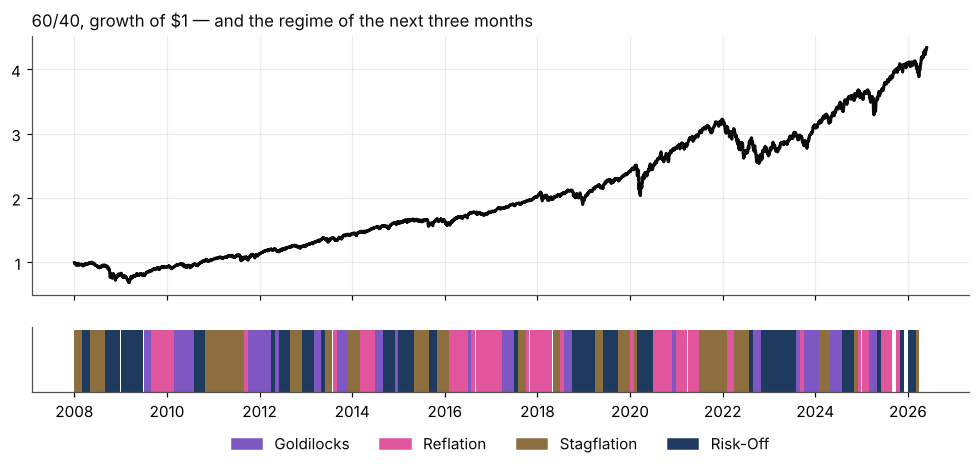

realised_forward,Risk_Off,Stagflation,Reflation,Goldilocks
months,64,57,55,41


In [2]:
reg = viz.read('results/baselines/regimes.csv')
base = viz.daily('results/baselines/daily_returns.csv')
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 4.2), sharex=True, height_ratios=[4, 1])
w = (1 + base['sixty_forty']).cumprod()
a1.plot(w.index, w, color=viz.INK); a1.set_title('60/40, growth of $1 — and the regime of the next three months')
viz.regime_strip(a2, reg['realised_forward']); a2.set_yticks([]); a2.grid(False)
viz.regime_legend(a2, anchor=(0.5, -0.45)); plt.show()
reg['realised_forward'].value_counts().rename('months').to_frame().T

**Reading.** The realised regime changes every few months and all four occur often (41–64 months each). There is no long, easy stretch to lean on.

## 2. Each regime has different winners

Annualised Sharpe of each asset in the month after the decision, grouped by the regime that was realised (left), next to the playbook weights fixed in advance (right). The left panel uses outcomes, so it is a description, not a strategy.

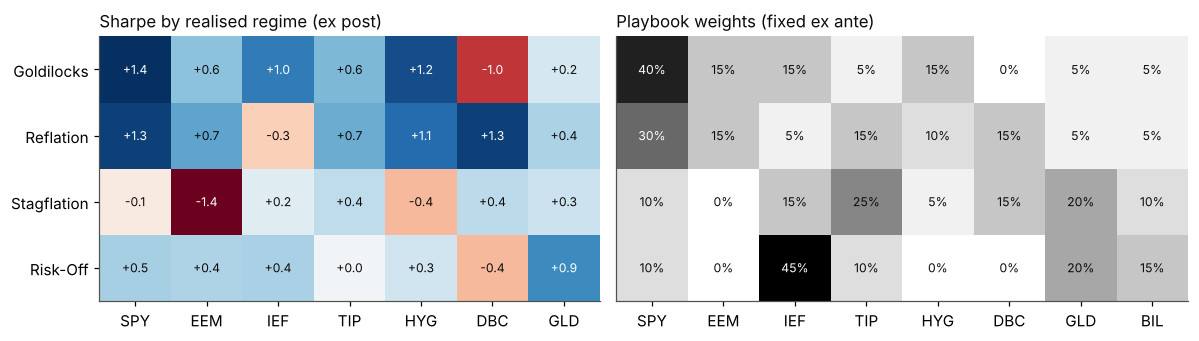

In [3]:
from lra import strategies as S
from lra.config import load_config
px = pd.read_csv(viz.DATA / 'etf_prices.csv', parse_dates=['date'], index_col='date')
assets = ['SPY', 'EEM', 'IEF', 'TIP', 'HYG', 'DBC', 'GLD']
m = px[assets + ['BIL']].resample('ME').last().pct_change()
ex = m[assets].sub(m['BIL'], axis=0).shift(-1)                      # return of the following month
lab = reg['realised_forward'].copy(); lab.index = lab.index.to_period('M').to_timestamp('M')
j = ex.join(lab.rename('regime')).dropna()
sharpe = j.groupby('regime')[assets].apply(lambda g: g.mean() / g.std() * np.sqrt(12)).loc[viz.REGIMES]
pb = S.playbook_matrix(load_config(viz.ROOT / 'configs' / 'strategy.toml'), assets + ['BIL']).loc[viz.REGIMES]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.2), width_ratios=[7, 8])
for ax, t, cm, f, title in [(a1, sharpe, 'RdBu', '{:+.1f}', 'Sharpe by realised regime (ex post)'),
                           (a2, pb, 'Greys', '{:.0%}', 'Playbook weights (fixed ex ante)')]:
    lim = np.abs(t.values).max()
    ax.imshow(t.values, cmap=cm, vmin=-lim if cm == 'RdBu' else 0, vmax=lim, aspect='auto')
    ax.set_xticks(range(t.shape[1]), t.columns); ax.set_yticks(range(4), [r.replace('_', '-') for r in t.index])
    for (i, k), v in np.ndenumerate(t.values):
        ax.text(k, i, f.format(v), ha='center', va='center', fontsize=8,
                color='white' if abs(v) > 0.6 * lim else viz.INK)
    ax.set_title(title); ax.grid(False)
a2.set_yticks([]); plt.tight_layout(); plt.show()

**Reading.** Equities and high yield earn in the growth-up regimes, commodities (DBC) in Reflation, Treasuries (IEF) and gold in Risk-Off, while equities, emerging markets and high yield lose in Stagflation. The playbook leans the same way. That is the premise of the whole study: *if* the regime can be called in advance, a fixed playbook can monetise it.

## 3. No baseline beats guessing

Four no-LLM forecasters, all walk-forward or rule-based: *climatology* (the base rate of regimes already published), the *rule* (the current 6-month trend persists), and logistic regression and gradient boosting (*ML logit*, *ML GBT*) trained on the same snapshot an LLM will see.

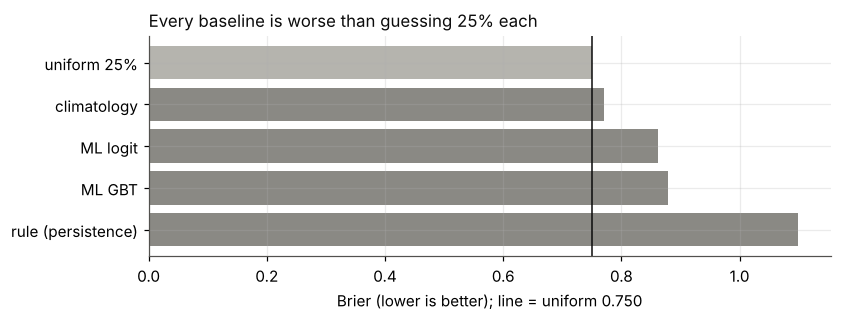

,hit_rate,brier
uniform 25%,19%,0.750
climatology,16%,0.770
ML logit,37%,0.861
ML GBT,32%,0.880
rule (persistence),33%,1.099


In [4]:
from lra import evaluation as ev
fair = viz.read('results/baselines/regimes_fair.csv')
y = reg['realised_forward'].dropna()
cols = lambda df, p: df[[f'{p}_{k}' for k in viz.REGIMES]].set_axis(viz.REGIMES, axis=1)
fc = {'uniform 25%': ev.uniform(reg.index), 'climatology': cols(fair, 'climatology'),
      'ML logit': cols(reg, 'logit'), 'ML GBT': cols(reg, 'gbt'), 'rule (persistence)': ev.hard(reg['rule'])}
scores = pd.DataFrame({k: ev.score(p, y) for k, p in fc.items()}).T[['hit_rate', 'brier']]
fig, ax = plt.subplots(figsize=(8, 2.6))
names = scores.index[::-1]
ax.barh(names, scores.brier[names], color=[viz.GREYS['uniform'] if n.startswith('uniform') else viz.GREYS['ml'] for n in names])
ax.axvline(0.75, color=viz.INK, lw=1); ax.set_xlabel('Brier (lower is better); line = uniform 0.750')
ax.set_title('Every baseline is worse than guessing 25% each'); plt.show()
viz.fmt(scores, pct=['hit_rate'])

**Reading.** **Key finding:** no baseline beats uniform. Climatology comes closest (0.770); the ML models score 0.861–0.880 and the rule, which commits fully to one regime, 1.099. Hit rates of 16–37% sit close to the 25% of chance. This is the bar for nb02: beat uniform, and beat ML given identical inputs.

## 4. Baseline portfolios

The playbook driven by the rule and by the ML forecasts, against 60/40, net of 2.5 bps.

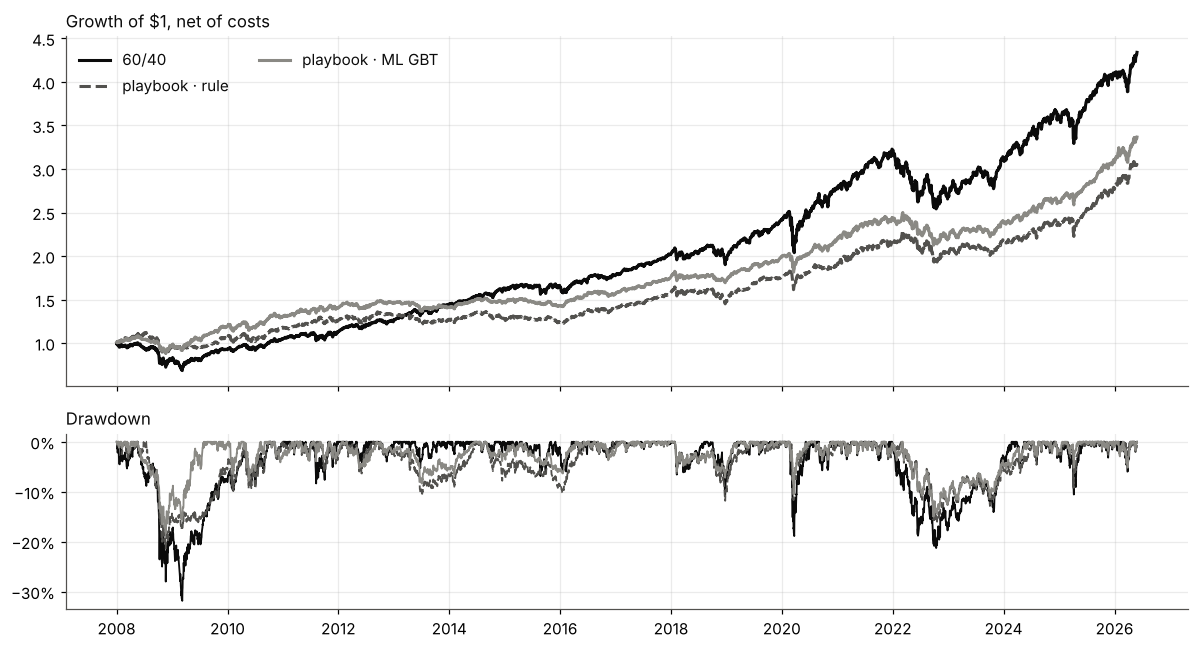

,ann_return,ann_vol,sharpe,max_drawdown,turnover_per_year
strategy,,,,,
sixty_forty,8.3%,11.1%,0.66,-32%,0.11
rule_playbook,6.3%,8.3%,0.62,-21%,1.09
ml_logit_playbook,6.4%,8.1%,0.64,-26%,1.20
ml_gbt_playbook,6.8%,7.4%,0.75,-18%,1.51


In [5]:
met = pd.read_csv(viz.RESULTS / 'baselines' / 'metrics.csv')
head = met[met.cost_bps == 2.5].set_index('strategy').loc[
    ['sixty_forty', 'rule_playbook', 'ml_logit_playbook', 'ml_gbt_playbook'],
    ['ann_return', 'ann_vol', 'sharpe', 'max_drawdown', 'turnover_per_year']]
viz.equity_drawdown({'60/40': (base['sixty_forty'], viz.INK, '-'),
                     'playbook · rule': (base['rule_playbook'], viz.GREYS['rule'], '--'),
                     'playbook · ML GBT': (base['ml_gbt_playbook'], viz.GREYS['ml'], '-')}); plt.show()
viz.fmt(head, pct1=['ann_return', 'ann_vol'], pct=['max_drawdown'], d2=['sharpe', 'turnover_per_year'])

**Reading.** Playbooks trade return for risk: the ML GBT playbook earns 6.8% a year against 8.3% for 60/40, at two-thirds of the volatility and about half the drawdown (−18% against −32%), for a Sharpe of 0.75 against 0.66. Costs barely matter: 10 bps instead of 2.5 lowers any Sharpe here by at most 0.03. With one 18-year path, the standard error of an annualised Sharpe is about 0.24, so these are not rankings.

## What we can and cannot claim

- **No no-LLM forecaster beats uniform** on Brier (best: climatology 0.770 against 0.750).
- **Regime playbooks lower risk** relative to 60/40; their Sharpe edge (≈ 0.1) is within noise.
- **Outcomes are labelled with today's data vintage**; nb03 shows that first-release labels change 33 of 217 months and no ranking.

## Next

nb02 puts an LLM on the same snapshots and the same playbook.